<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
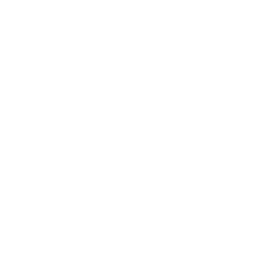
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Interpolazione dell'arruolamento da trimestrale a mensile</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutico / Operazioni cliniche &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi esecutiva

Questo esempio pratico converte i conteggi **trimestrali** di arruolamento di uno studio clinico in stime **mensili** con PROC EXPAND, in modo che la pianificazione delle risorse a livello di sito possa procedere su cadenza mensile. Lo studio sintetico copre **quattro siti sperimentali** in due regioni (Nord America ed Europa) nell'arco di **otto trimestri** (dal Q1 2024 al Q4 2025), per un totale di **32 osservazioni trimestrali**. PROC EXPAND interpola la serie di ciascun sito dalla frequenza trimestrale a quella mensile, trasformando quelle 32 righe trimestrali in **96 righe mensili**. I conteggi degli arruolati sono interpolati con `METHOD=JOIN` (lineare a tratti, che mantiene ogni stima non negativa) e il cumulato progressivo è interpolato con `METHOD=SPLINE`. La serie mensile interpolata passa esattamente per i punti di ancoraggio trimestrali originali, quindi la conversione aggiunge dettaglio infra-trimestrale senza alterare le cifre trimestrali già riportate dallo studio.

## Fonti dei dati

| Fonte | Descrizione | Record |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | Conteggi trimestrali di arruolamento per sito (4 siti x 8 trimestri) | 32 |
| WORK.SITE_MASTER | Anagrafica dei siti: nome, paese, regione, PI | 4 |

---

In [1]:
/* --------------------------------------------------------
   Generate quarterly enrollment counts by site.
   4 sites x 8 quarters (Q1-2024 through Q4-2025) = 32 rows.
   A ramp-up curve (slow start, plateau) plus a mild seasonal
   term and small noise produces a realistic enrollment shape.
   -------------------------------------------------------- */
DATI work.enrollment_qtr;
    CHIAMARE streaminit(42);
    FORMATO quarter_date yyq7.;
    VETTORE capacity[4] _temporary_ (12 9 14 8);
    FARE site_num = 1 FINO_A 4;
        site_id = cat('SITE-', PUT(site_num, z3.));
        region  = ifc(site_num <= 2, 'NORD_AMERICA', 'EUROPA');
        base_rate = capacity[site_num];
        FARE qtr_seq = 0 FINO_A 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            USCITA;
        FINE;
    FINE;
    RIMUOVERE site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
ESEGUIRE;

/* Running cumulative enrollment within each site */
PROCEDURA ORDINARE DATI=work.enrollment_qtr;
    PER site_id quarter_date;
ESEGUIRE;

DATI work.enrollment_qtr;
    IMPOSTARE work.enrollment_qtr;
    PER site_id;
    CONSERVARE cum_enrolled 0;
    SE_COND first.site_id ALLORA cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    RIMUOVERE cum_enrolled;
ESEGUIRE;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Site master reference table (4 sites, 2 regions)
   -------------------------------------------------------- */
DATI work.site_master;
    LUNGHEZZA site_id $8 site_name $40 region $20 country $20 pi_name $30;
    VETTORE names[4] $40 _temporary_ (
        'Metro General Hospital'   'University Medical Center'
        'London Royal Infirmary'   'Berlin Charite Campus'
    );
    VETTORE countries[4] $20 _temporary_ ('USA' 'USA' 'UK' 'Germany');
    FARE i = 1 FINO_A 4;
        site_id   = cat('SITE-', PUT(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, 'NORD_AMERICA', 'EUROPA');
        pi_name   = cat('Dr. Investigator-', PUT(i, z2.));
        USCITA;
    FINE;
    RIMUOVERE i;
ESEGUIRE;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Baseline quarterly enrollment summary by region
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.enrollment_qtr n sum mean MAX;
    CLASSE region;
    VARIABILE enrolled_count cumulative_enrolled;
    ETICHETTA region="Regione" enrolled_count="Arruolati" cumulative_enrolled="Arruolamento Cumulato";
    USCITA out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
ESEGUIRE;

PROCEDURA STAMPARE DATI=work.qtr_baseline noobs;
    ETICHETTA region="Regione" total_enrolled="Arruolati Totali"
          avg_per_quarter="Media per Trimestre" max_cumulative="Cumulato Massimo";
    TITOLO "Riferimento di Base dell'Arruolamento Trimestrale per Regione";
ESEGUIRE;


                                                  The MEANS Procedure

                                      Analysis Variable : enrolled_count Arruolati

        Regione               N Obs            Sum           Mean        Maximum
        ------------------------------------------------------------------------
        EUROPA                   16    120.0000000      7.5000000     13.0000000
        NORD_AMERICA             16    115.0000000      7.1875000     10.0000000
        ------------------------------------------------------------------------

                             Analysis Variable : cumulative_enrolled Arruolamento Cumulato

        Regione               N Obs            Sum           Mean        Maximum
        ------------------------------------------------------------------------
        EUROPA                   16    493.0000000     30.8125000     81.0000000
        NORD_AMERICA             16    474.0000000     29.6250000     63.0000000
        ---------------


NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


Il riferimento di base conferma un disegno bilanciato: ciascuna regione contribuisce con **16 osservazioni trimestrali**. Il Nord America arruola in totale **115 soggetti** (media **7,19** per sito-trimestre) e l'Europa **120** (media **7,50**). Il conteggio cumulato più alto raggiunto nel corso degli otto trimestri è di **81** soggetti (il SITE-003 europeo) contro i **63** del Nord America.

---

                             Riferimento di Base dell'Arruolamento Trimestrale per Regione                              




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


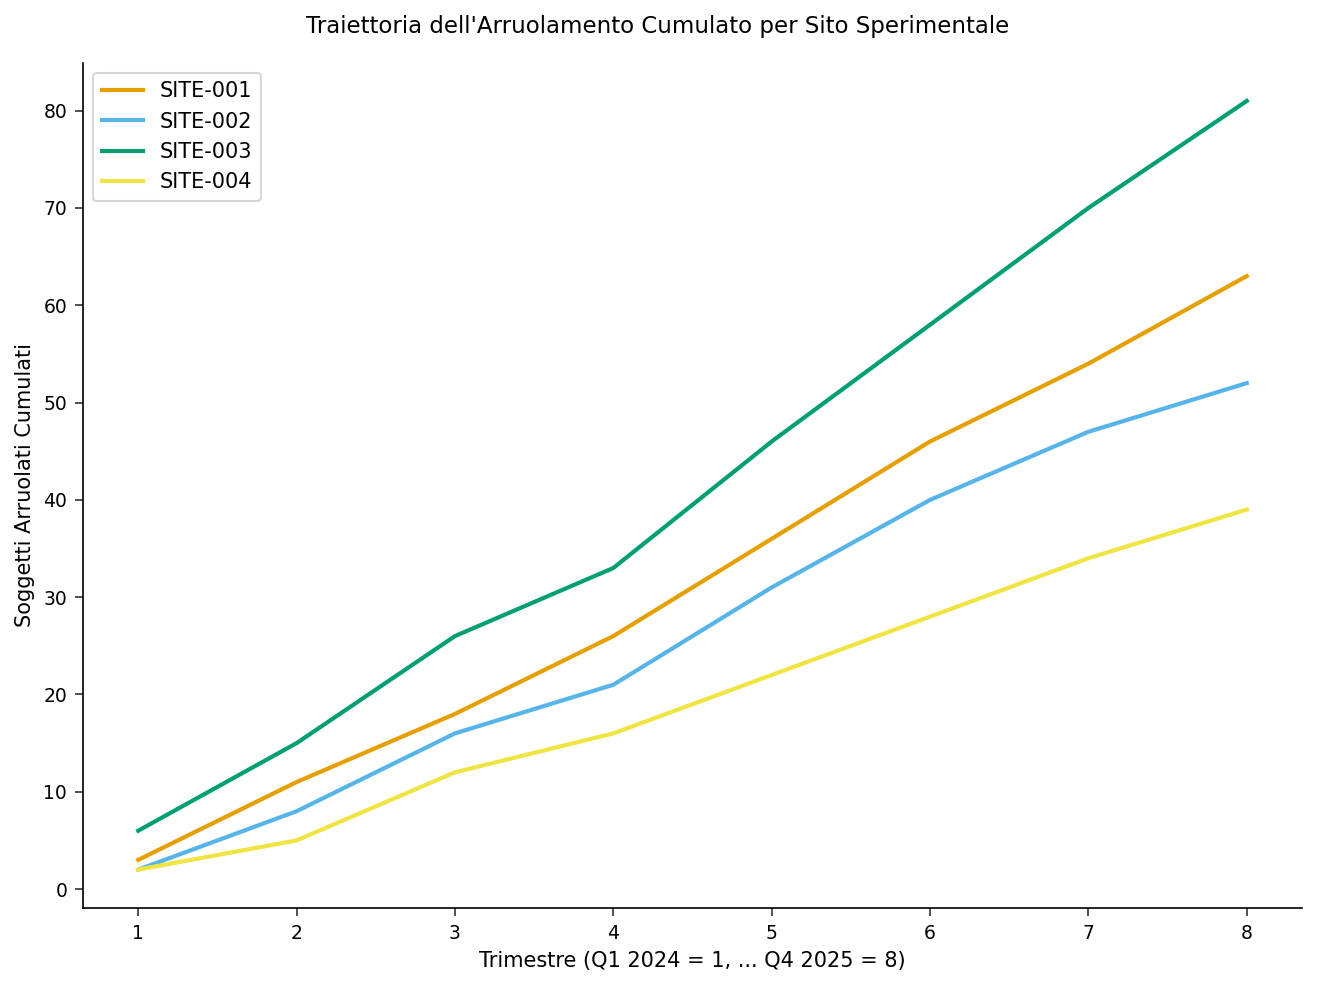

In [4]:
/* --------------------------------------------------------
   Quarterly cumulative-enrollment trajectory by site.
   Plotted against a quarter index (1..8) for a clean axis.
   -------------------------------------------------------- */
DATI work.traj;
    IMPOSTARE work.enrollment_qtr;
    PER site_id;
    CONSERVARE quarter_index 0;
    SE_COND first.site_id ALLORA quarter_index = 0;
    quarter_index + 1;
ESEGUIRE;

PROCEDURA SGPLOT DATI=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS ETICHETTA='Trimestre (Q1 2024 = 1, ... Q4 2025 = 8)'
        integer VALUES=(1 FINO_A 8 PER 1);
    YAXIS ETICHETTA='Soggetti Arruolati Cumulati';
    TITOLO "Traiettoria dell'Arruolamento Cumulato per Sito Sperimentale";
ESEGUIRE;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND requires the ID variable sorted within each
   BY group, so sort by site then quarter before converting.
   -------------------------------------------------------- */
PROCEDURA ORDINARE DATI=work.enrollment_qtr;
    PER site_id quarter_date;
ESEGUIRE;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Convert quarterly enrollment to monthly estimates.

   FROM=QTR / TO=MONTH on the PROC statement set the input and
   output frequencies; PROC EXPAND interpolates each BY group
   (site) independently along the ID date.

   enrolled_count   -> METHOD=JOIN   (piecewise-linear; the flow
                       value stays non-negative between anchors)
   cumulative_enrolled -> METHOD=SPLINE (smooth monotone curve)
   -------------------------------------------------------- */
PROCEDURA expand DATI=work.enrollment_qtr
            out=work.enrollment_monthly
            FROM=qtr FINO_A=month;
    PER site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=FINE     METHOD=SPLINE;
ESEGUIRE;


                             Riferimento di Base dell'Arruolamento Trimestrale per Regione                              




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                             Riferimento di Base dell'Arruolamento Trimestrale per Regione                              




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


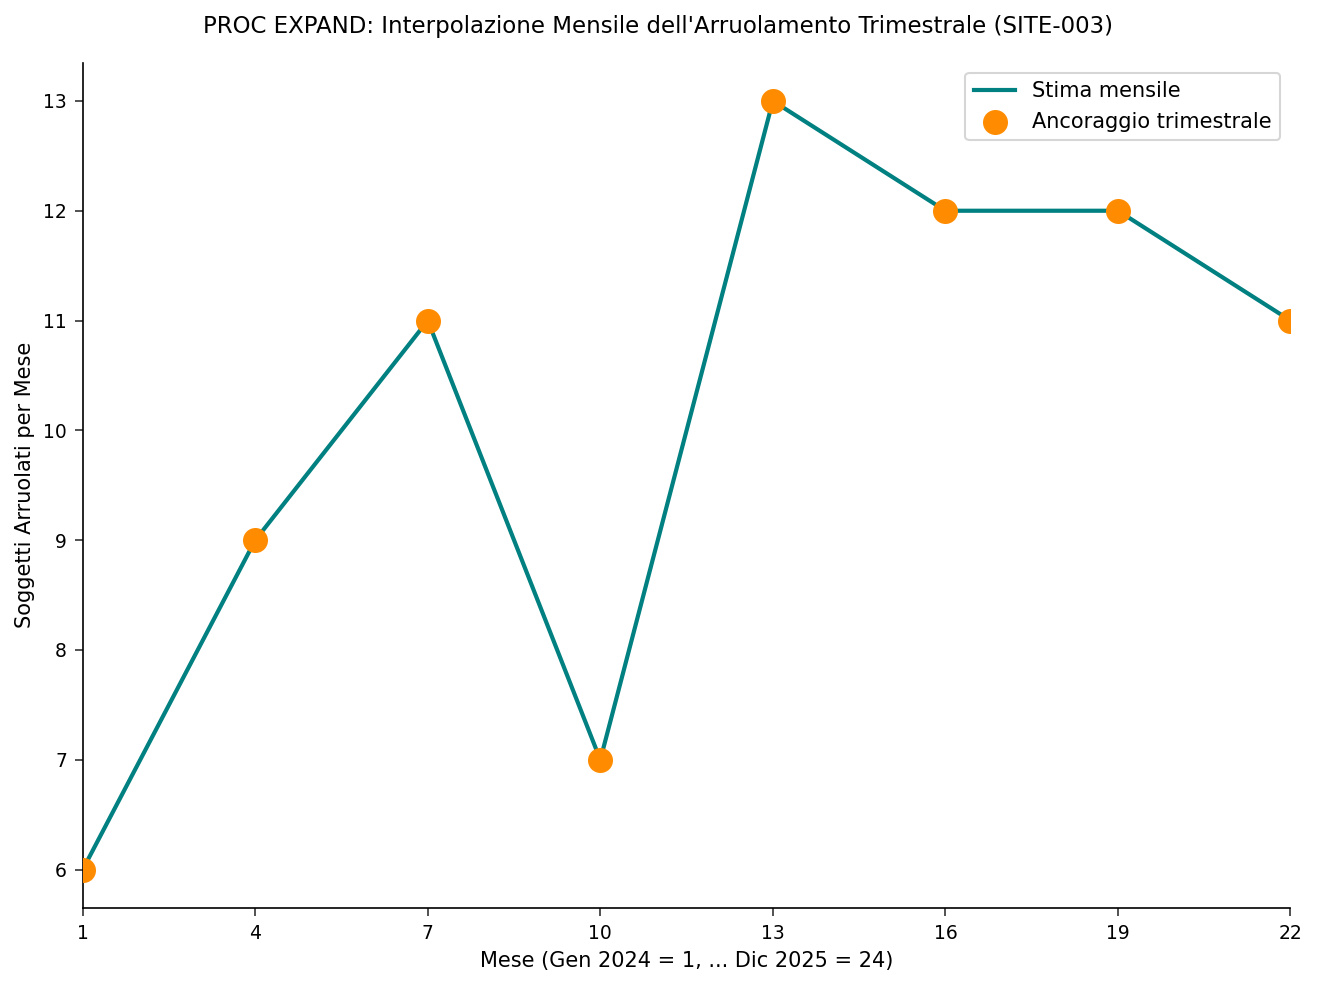

In [7]:
/* --------------------------------------------------------
   The ID variable now carries monthly dates. Re-format it and
   add a within-site month index (1..24) for plotting.
   -------------------------------------------------------- */
DATI work.enrollment_monthly;
    IMPOSTARE work.enrollment_monthly;
    PER site_id;
    FORMATO month_date monyy7.;
    month_date = quarter_date;
    CONSERVARE month_index 0;
    SE_COND first.site_id ALLORA month_index = 0;
    month_index + 1;
    /* flag the quarter-anchor months (1, 4, 7, ...) */
    SE_COND mod(month_index - 1, 3) = 0 ALLORA anchor = enrolled_count;
    ALTRIMENTI anchor = .;
ESEGUIRE;

/* Show the conversion for one site: interpolated monthly line
   passing through the original quarterly anchor points. */
PROCEDURA SGPLOT DATI=work.enrollment_monthly;
    DOVE site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel='Stima mensile';
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel='Ancoraggio trimestrale';
    XAXIS ETICHETTA='Mese (Gen 2024 = 1, ... Dic 2025 = 24)'
        integer VALUES=(1 FINO_A 24 PER 3);
    YAXIS ETICHETTA='Soggetti Arruolati per Mese';
    TITOLO "PROC EXPAND: Interpolazione Mensile dell'Arruolamento Trimestrale (SITE-003)";
ESEGUIRE;


In [8]:
/* --------------------------------------------------------
   Join the monthly estimates to site metadata, then summarize
   monthly enrollment by region.
   -------------------------------------------------------- */
PROCEDURA SQL;
    CREARE TABELLA work.enrollment_monthly_region AS
    SELEZIONARE e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    FROM work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER PER s.region, e.site_id, e.month_date;
QUIT;

PROCEDURA MEDIE DATI=work.enrollment_monthly_region n sum mean;
    CLASSE region;
    VARIABILE monthly_estimate cumulative_estimate;
    ETICHETTA region="Regione" monthly_estimate="Stima Mensile" cumulative_estimate="Stima Cumulata";
    USCITA out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
ESEGUIRE;

PROCEDURA STAMPARE DATI=work.region_monthly_summary noobs;
    ETICHETTA region="Regione" total_monthly_enrolled="Totale Arruolati Mensile"
          avg_monthly_rate="Tasso Medio Mensile";
    TITOLO "Stime Mensili per Regione";
ESEGUIRE;


                             Riferimento di Base dell'Arruolamento Trimestrale per Regione                              

                             Riferimento di Base dell'Arruolamento Trimestrale per Regione                              

                                                  The MEANS Procedure

                                   Analysis Variable : monthly_estimate Stima Mensile

        Regione               N Obs            Sum           Mean
        ---------------------------------------------------------
        EUROPA                   44    336.0000000      7.6363636
        NORD_AMERICA             44    326.0000000      7.4090909
        ---------------------------------------------------------

                                 Analysis Variable : cumulative_estimate Stima Cumulata

        Regione               N Obs            Sum           Mean
        ---------------------------------------------------------
        EUROPA                   48   1367.000


NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### Interpretazione

PROC EXPAND ha convertito i **32 record trimestrali** (4 siti x 8 trimestri) in **96 record mensili** usando la conversione di frequenza lungo la data di ciascun sito. La serie mensile interpolata passa esattamente per i valori di ancoraggio trimestrali originali, come mostra il grafico del SITE-003: i punti arancioni sono gli otto conteggi trimestrali riportati e la linea verde acqua è la stima mensile disaggregata che li collega.

Su base mensile le due regioni procedono in modo molto simile. L'Europa registra una media di **7,64** soggetti arruolati per sito-mese e il Nord America **7,41**, con totali mensili regionali di **336** e **326** soggetti nell'orizzonte interpolato. Poiché `METHOD=JOIN` non estrapola oltre l'ultimo ancoraggio trimestrale, i mesi finali del trimestre parziale non riportano alcuna stima e sono esclusi dalle medie mensili, il che rappresenta la scelta prudente per la pianificazione futura.

Queste proiezioni mensili consentono alle operazioni cliniche di passare da una cadenza di pianificazione trimestrale a una mensile -- dimensionando le spedizioni di fornitura del farmaco, programmando le visite di monitoraggio e riportando l'arruolamento al Comitato di Monitoraggio della Sicurezza dei Dati (DSMB) -- senza ridefinire alcuna delle cifre trimestrali che lo studio ha già consolidato.

---

In [9]:
/* --------------------------------------------------------
   Export monthly enrollment projections for downstream
   planning tools.
   -------------------------------------------------------- */
PROCEDURA EXPORT DATI=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
ESEGUIRE;

PROCEDURA EXPORT DATI=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
ESEGUIRE;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con la tecnologia di <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>